# Solving the seismic wave equation defined in 1-dimension.

$u_{tt}=v^2u_{xx}$,

where $v$ represents the velocity.

# Here are the boundary and initial conditions

1. $u(0, t) = \cos(2\pi*t)$
2. $u(1, t) = \cos\left[2\pi*(t-\frac{1}{2})\right]$
3. $u(x, 0) = \cos(\pi*x)$
4. $\frac{du}{dt}|_{(x, 0)} = 2\pi\sin(\pi*x)$

In [1]:
pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.4 MB/s eta 0:00:00


In [2]:
import deepxde as dde
from deepxde.backend import tf
import torch
import torch.nn as nn

No backend selected.
Finding available backend...
Found tensorflow
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "tensorflow". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


In [3]:
# Hyperparams
velocity = 2
num_epochs = 10000

In [4]:
def analytical_solution(x, t):
    return torch.cos(2*torch.pi * (t - x/velocity))

## Setting up PINN

In [5]:
class PINN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(PINN, self).__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.linear2 = nn.Linear(hidden_size, hidden_size)
        self.linear3 = nn.Linear(hidden_size, hidden_size)
        self.linear4 = nn.Linear(hidden_size, 1)
        self.tanh = nn.Tanh()

    def forward(self, x, t):
        x = torch.concat([x, t], dim=1)
        out = self.linear1(x)
        out = self.tanh(out)
        out = self.linear2(out)
        out = self.tanh(out)
        out = self.linear3(out)
        out = self.tanh(out)
        out = self.linear4(out)
        return out

## Total Loss function

In [6]:
def pde_residual(model, x, t, velocity):
    u = model(x, t)
    x.requires_grad = True
    t.requires_grad = True

    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    u_tt = torch.autograd.grad(u_t, t, grad_outputs=torch.ones_like(t), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(x), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(x), create_graph=True)[0]

    residual = u_tt - (velocity**2)*u_xx
    loss = torch.mean(torch.square(residual))
    return loss

In [7]:
def boundary_loss(model, x, t, velocity):
    u = model(x, t)

    left_mask = (x == 0)
    right_mask = (x == 1)

    u_left = u[left_mask.squeeze()]
    t_left = t[left_mask.squeeze()]

    u_right = u[right_mask.squeeze()]
    t_right = t[right_mask.squeeze()]

    target_left = torch.cos(2 * torch.pi * t_left)
    target_right = torch.cos(2 * torch.pi * (t_right - 0.5))

    loss_left = torch.mean((u_left - target_left) ** 2)
    loss_right = torch.mean((u_right - target_right) ** 2)

    return loss_left + loss_right

In [8]:
def initial_loss(model, x, t):
    u = model(x, t)
    x.requires_grad = True
    t.requires_grad = True

    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_tt = torch.autograd.grad(u_t, t, torch.ones_like(u_t), create_graph=True)[0]

    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]

    correct_val = torch.cos(2*torch.pi * (t - x/velocity))
    loss_1 = torch.mean(torch.square(correct_val - u))

    loss_2 = torch.mean(torch.square(u_tt-(velocity**2)*u_xx))

    total_loss = loss_1 + loss_2
    return total_loss

## Generating training data

In [9]:
# Generating data for pde training
x_colloc = torch.rand(1000, 1, requires_grad=True)
t_colloc = torch.rand(1000, 1, requires_grad=True)

# Generating data for bc_training
#x_bc = torch.zeros(1000, 1, requires_grad=False)
x_bc = torch.cat([torch.zeros(500, 1), torch.ones(500, 1)], dim=0)
t_bc = torch.rand(1000, 1, requires_grad=False)

# Generating data for initial_conditions training
x_ic = torch.rand(1000, 1, requires_grad=True)
t_ic = torch.rand(1000, 1, requires_grad=True)

## Training PINN for 10000 epochs

In [10]:
# Training loop
model = PINN(2, 25)
optimizer =  torch.optim.Adam(model.parameters(), lr=0.01)
for epoch in range(num_epochs):
    optimizer.zero_grad()

    pde_loss = pde_residual(model, x_colloc, t_colloc, velocity)
    bc_loss = boundary_loss(model, x_bc, t_bc, velocity)
    init_loss = initial_loss(model, x_ic, t_ic)
    total_loss = pde_loss + bc_loss + init_loss

    total_loss.backward()
    optimizer.step()

    if epoch%100 == 0:
        print(f"epoch:{epoch}/{num_epochs} || loss:{total_loss.item()}")

epoch:0/10000 || loss:1.5717328786849976
epoch:100/10000 || loss:0.387149453163147
epoch:200/10000 || loss:0.022040506824851036
epoch:300/10000 || loss:0.021185319870710373
epoch:400/10000 || loss:0.04118144512176514
epoch:500/10000 || loss:0.29299771785736084
epoch:600/10000 || loss:0.04767651855945587
epoch:700/10000 || loss:0.027409348636865616
epoch:800/10000 || loss:0.013923080638051033
epoch:900/10000 || loss:0.037096329033374786
epoch:1000/10000 || loss:0.09942188858985901
epoch:1100/10000 || loss:0.03399261087179184
epoch:1200/10000 || loss:0.036001455038785934
epoch:1300/10000 || loss:0.021864566951990128
epoch:1400/10000 || loss:0.005372058600187302
epoch:1500/10000 || loss:0.007788442075252533
epoch:1600/10000 || loss:0.006952486000955105
epoch:1700/10000 || loss:0.007040277123451233
epoch:1800/10000 || loss:0.003416967112571001
epoch:1900/10000 || loss:0.004090240690857172
epoch:2000/10000 || loss:0.006728745065629482
epoch:2100/10000 || loss:0.017426224425435066
epoch:2200

## Comparing the Analytical solution and the Model predictions

In [11]:
# Generating data to compare the analytical solution and the model predictions
import matplotlib.pyplot as plt

In [12]:

x = torch.linspace(0, 1, 1000)
t = torch.linspace(0, 1, 1000)

X, T = torch.meshgrid(x, t, indexing='ij')

In [13]:
X_flat = X.flatten().view(-1, 1)
T_flat = T.flatten().view(-1, 1)

In [14]:
u_analytic = analytical_solution(X_flat, T_flat)
u_pred = model(X_flat, T_flat).detach()

u_analytic = u_analytic.view(1000, 1000)
u_pred = u_pred.view(1000, 1000)

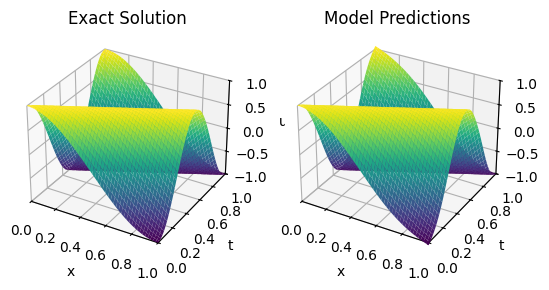

In [15]:
# Plotting the curves
fig = plt.figure()
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(X.numpy(), T.numpy(), u_analytic.numpy(), cmap='viridis')
ax.set_title("Exact Solution")
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([-1, 1])

ax = fig.add_subplot(122, projection='3d')
ax.plot_surface(X.numpy(), T.numpy(), u_pred.numpy(), cmap='viridis')
ax.set_title("Model Predictions")
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([-1, 1])

plt.show()

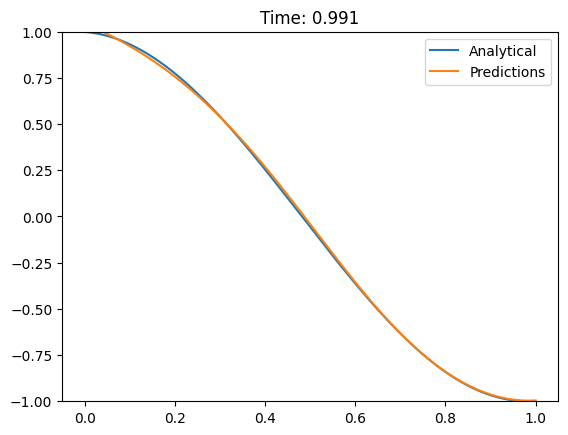

In [17]:
import matplotlib.animation as animation
from IPython.display import HTML
from matplotlib.animation import FFMpegWriter

fig, ax = plt.subplots()

line1, = ax.plot(x.numpy(), u_analytic[:, 0].numpy(), label='Analytical')
line2, = ax.plot(x.numpy(), u_pred[:, 0].numpy(), label='Predictions')

ax.set_ylim(-1, 1)
ax.legend()

def update(i):
    line1.set_ydata(u_analytic[:, i].numpy())
    line2.set_ydata(u_pred[:, i].numpy())
    ax.set_title(f"Time: {t[i].item():.3f}")
    return line1, line2

ani = animation.FuncAnimation(
    fig,
    update,
    frames=range(0, 1000, 10),
    interval=50,
    blit=True
)

HTML(ani.to_jshtml())
#ani.save("wave_animation.mp4", writer=FFMpegWriter(fps=20))

In [18]:
#saving animation on local computer
#from google.colab import files
#files.download("wave_animation.mp4")